In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загрузка данных

Для решения задачи оценки здоровья бренда был выбран датасет [Title and Headline Sentiment Prediction](https://www.kaggle.com/datasets/adarshsng/title-and-headline-sentiment-prediction/), содержащий следующую структуру:

- `Title` - заголовок новости;
- `Headline` - краткий текст новости;
- `Source` - источник новости;
- `Topic` - тематика;
- `PublishDate` - дата и время публикации;
- `SentimentTitle` - оценка тональности заголовка;
- `SentimentHeadline` - оценка тональности текста.

In [2]:
data = pd.read_csv('title_and_headline_train_file.csv')
data.head()

,IDLink,Title,Headline,Source,Topic,PublishDate,Facebook,GooglePlus,LinkedIn,SentimentTitle,SentimentHeadline
0,Tr3CMgRv1N,Obama Lays Wreath at Arlington National Cemetery,Obama Lays Wreath at Arlington National Cemete...,USA TODAY,obama,2002-04-02 00:00:00,-1,-1,-1,0.000000,-0.053300
1,Wc81vGp8qZ,A Look at the Health of the Chinese Economy,"Tim Haywood, investment director business-unit...",Bloomberg,economy,2008-09-20 00:00:00,-1,-1,-1,0.208333,-0.156386
2,zNGH03CrZH,Nouriel Roubini: Global Economy Not Back to 2008,"Nouriel Roubini, NYU professor and chairman at...",Bloomberg,economy,2012-01-28 00:00:00,-1,-1,-1,-0.425210,0.139754
3,3sM1H0W8ts,Finland GDP Expands In Q4,Finland's economy expanded marginally in the t...,RTT News,economy,2015-03-01 00:06:00,-1,-1,-1,0.000000,0.026064
4,wUbnxgvqaZ,"Tourism, govt spending buoys Thai economy in J...",Tourism and public spending continued to boost...,The Nation - Thailand&#39;s English news,economy,2015-03-01 00:11:00,-1,-1,-1,0.000000,0.141084


Отфильтруем датасет по колонке `Topic`, оставив только новости, относящиеся к бренду Microsoft.

In [3]:
data = data[data['Topic'] == 'microsoft']
data = data.reset_index()
data = data[['Title', 'Headline', 'Source', 'PublishDate', 'SentimentTitle', 'SentimentHeadline']]
data.head()

,Title,Headline,Source,PublishDate,SentimentTitle,SentimentHeadline
0,Intellitec Solutions to Host 13th Annual Sprin...,Over 100 attendees expected to see latest vers...,PRWeb,2015-03-01 00:19:00,-0.075378,0.036773
1,Microsoft's new Windows 10 ad targets Apple,"New Delhi, Feb.29 : Technology giant Microsoft...",New Kerala,2015-03-01 01:32:00,-0.059536,-0.081715
2,Microsoft Project Centennial seen with “univer...,"Microsoft may have burned off one bridge, but ...",SlashGear,2015-03-01 02:14:00,0.000000,0.002550
3,Microsoft sneaks onto Android while Android sn...,The platform battles are back MWC16 +Analysis ...,The Register,2015-03-01 02:15:00,0.000000,0.052670
4,"HoloLens dev edition costs £2,000 with new Con...",Microsoft’s AR headset is being made available...,Metro,2015-03-01 02:18:00,0.000000,0.079434


Посмотрим на коэффициент корреляции между оценкой тональности заголовка и новости. Заметим, что значения имеют слабую линейную связь - коэффициент корреляции Пирсона равен 0.18. Это может быть связано с журналистским приемом кликбейтных заголовков, когда для привлечения внимания используется сильное (положительное или отрицательное) утверждение, не подтверждающееся информацией в лиде новости. 

In [4]:
data[['SentimentTitle', 'SentimentHeadline']].corr()

,SentimentTitle,SentimentHeadline
SentimentTitle,1.000000,0.181956
SentimentHeadline,0.181956,1.000000


In [5]:
mean_val_title = data['SentimentTitle'].mean()
std_val_title = data['SentimentTitle'].std()

mean_val_head = data['SentimentHeadline'].mean()
std_val_head = data['SentimentHeadline'].std()

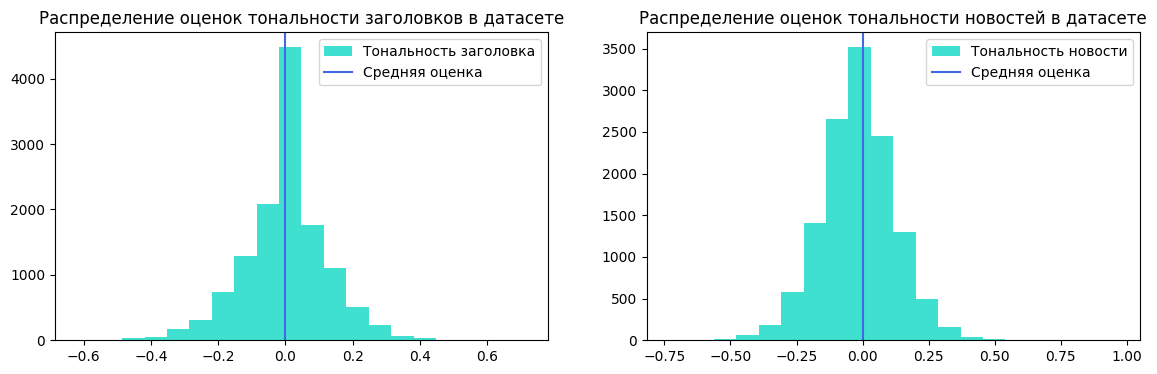

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['SentimentTitle'], bins=20, color='turquoise', label='Тональность заголовка')
axes[0].axvline(mean_val_title, color='royalblue', label='Средняя оценка')
axes[0].set_title('Распределение оценок тональности заголовков в датасете')
axes[0].legend()

axes[1].hist(data['SentimentHeadline'], bins=20, color='turquoise', label='Тональность новости')
axes[1].axvline(mean_val_title, color='royalblue', label='Средняя оценка')
axes[1].set_title('Распределение оценок тональности новостей в датасете')
axes[1].legend()

plt.grid(False)
plt.show()

Среднее значение оценки тональностей немного смещено в сторону отрицательных значений на обоих графиках. Для назначения лейбла тональности заголовка и новости разделим датасет по правилу одной сигмы.

In [7]:
lower_bound_title = mean_val_title - std_val_title
upper_bound_title = mean_val_title + std_val_title

lower_bound_head = mean_val_head - std_val_head
upper_bound_head = mean_val_head + std_val_head

def assign_sentiment(score, lower_bound, upper_bound):
    if score < lower_bound:
        return -1
    elif score > upper_bound:
        return +1
    else:
        return 0
    
data["TitleLabel"] = data["SentimentTitle"].apply(assign_sentiment, args=(lower_bound_title, upper_bound_title))
data["HeadlineLabel"] = data["SentimentHeadline"].apply(assign_sentiment, args=(lower_bound_head, upper_bound_head))

Далее отфильтруем только те строки, где лейбл тональности заголовка и текста новости совпадает.

In [8]:
data = data[data["TitleLabel"] == data["HeadlineLabel"]]
data = data.drop(["SentimentTitle", "SentimentHeadline", "HeadlineLabel"], axis=1)
data = data.rename(columns={"TitleLabel": "Target"})

Визуально оценим корректность разбиения.

*Негатив*

In [9]:
data_neg = data[data['Target'] == -1]
data_neg = data_neg.reset_index()
data_neg.loc[102, 'Headline']

"A configuration error in Microsoft's Azure Active Directory service is preventing customers from accessing a wide range of Microsoft services hosted in Europe, including Office 365 and Visual Studio Team Services. "

In [10]:
data_neg.loc[387, 'Headline']

"Microsoft has dropped bitcoin payments, just over a year after announcing it would support the virtual currency at its Windows Store. A post with the heading &quot;Microsoft Store doesn't accept bitcoin&quot; says: &quot;You can no longer redeem bitcoin into your Microsoft account. "

*Позитив*

In [11]:
data_pos = data[data['Target'] == 1]
data_pos = data_pos.reset_index()
data_pos.loc[278, 'Headline']

'On Thursday, Microsoft reported solid quarterly earnings, and investors are pleased. The stock is up about 3% after-hours. Unlike Netflix and its'

In [12]:
data_pos.loc[407, 'Headline']

'When we think of the software industry, the first name that comes to our mind is Microsoft Corporation MSFT . Its operating systems are installed'

*Нейтрал*

In [13]:
data_neu = data[data['Target'] == 0]
data_neu = data_neu.reset_index()
data_neu.loc[1695, 'Headline']

'SAN JOSE, Calif.--(BUSINESSWIRE)-- Kaazing, chief contributor to the WebSocket standard, today announced the launch of Kaazing WebSocket Intercloud Connect (KWIC) on the Microsoft Azure Marketplace. With '

In [14]:
data_neu.loc[5479, 'Headline']

"Microsoft is letting developers pre-order the HoloLens development edition today, but it's also detailing exactly what's inside the headset."

Можно сделать вывод, что большая часть новостей классифицирована корректно. В то же время для PR-департамента компании восприятие той или иной публикации может несколько отличаться.

Финальный датасет состоит из 7671 наблюдения.

In [15]:
data.shape

(7671, 5)

Распределение таргета таково, что в датасете преобладают нейтральные новости - около 89% всего датасета. Негатив и позитив составляют примерно равные доли - по 5-6%.

In [16]:
data['Target'].value_counts()

Target
 0    6810
-1     437
 1     424
Name: count, dtype: int64

В датасете содержатся статьи за период с 1 марта 2015 года по 29 марта 2016 года.

In [17]:
data["PublishDate"] = pd.to_datetime(data["PublishDate"])

min_date = data['PublishDate'].min()
max_date = data['PublishDate'].max()

min_date, max_date

(Timestamp('2015-03-01 00:19:00'), Timestamp('2016-03-29 01:38:00'))

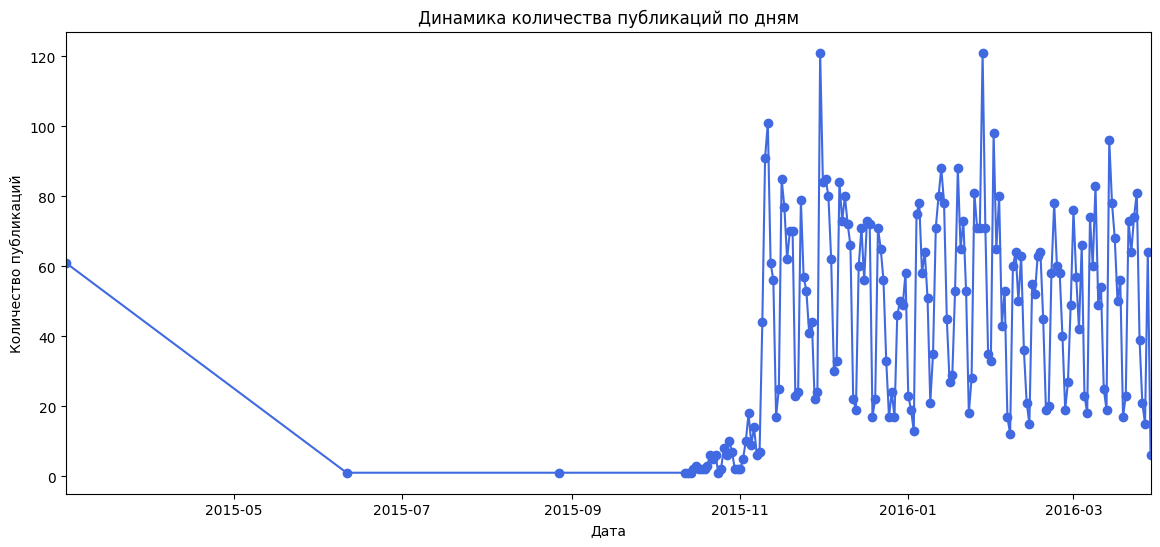

In [18]:
df = data.copy()
df["Day"] = df["PublishDate"].dt.date
daily_counts = df.groupby("Day").size()

plt.figure(figsize=(14, 6))
daily_counts.plot(kind="line", color="royalblue", marker="o")

plt.xlim(min_date, max_date)
plt.xlabel("Дата")
plt.ylabel("Количество публикаций")
plt.title("Динамика количества публикаций по дням")

plt.show()

На графике динамики количества публикаций заметим, что с июня 2015 по октябрь 2015 статьи отсутствуют. Проверив оригинальный датасет, мы можем прийти к выводу об ошибке сбора данных, оказавших влияние на финальное распределение статей во времени. Для нашей задачи этот факт не играет большой роли, однако полагаем, что тестирование reasoning-модели будет корректнее проводить на публикациях после ноября 2015.

In [19]:
data.head()

,Title,Headline,Source,PublishDate,Target
0,Intellitec Solutions to Host 13th Annual Sprin...,Over 100 attendees expected to see latest vers...,PRWeb,2015-03-01 00:19:00,0
1,Microsoft's new Windows 10 ad targets Apple,"New Delhi, Feb.29 : Technology giant Microsoft...",New Kerala,2015-03-01 01:32:00,0
2,Microsoft Project Centennial seen with “univer...,"Microsoft may have burned off one bridge, but ...",SlashGear,2015-03-01 02:14:00,0
3,Microsoft sneaks onto Android while Android sn...,The platform battles are back MWC16 +Analysis ...,The Register,2015-03-01 02:15:00,0
4,"HoloLens dev edition costs £2,000 with new Con...",Microsoft’s AR headset is being made available...,Metro,2015-03-01 02:18:00,0
